# Post-BBN radioactive-decay evolution (the "Decay Time" / DT era)

Standard BBN integration stops at `T_end = 0.001 MeV`, i.e. cosmic time
`t_end ≈ 1.3×10⁶ s ≈ 15 days`.  At that point several nuclides are still
radioactive and keep decaying for years to millions of years, long after all
thermonuclear reactions have frozen out.  The **DT era**
propagates the abundance vector forward under the *constant* decay matrix `D`,

$$\frac{dY}{dt} = D\,Y \quad\Longrightarrow\quad Y(t) = \exp\!\big(D\,(t-t_{\rm end})\big)\,Y(t_{\rm end}),$$

solved exactly with `scipy.linalg.expm` (robust to the ~16-decade spread of
decay constants, from B15 at T½ ≈ 10 ms to Be10 at T½ ≈ 1.39 Myr).

This notebook runs the **large** network with `decay_era=True` and plots
`Y(t)` for every tracked nuclide from ~1 s out to `t_end + 1 Gyr`.  When
`decay_era=True`, the public abundance interpolator is extended across the
LT→DT boundary, so `run[species](t)` (and `get_quantity(..., t=...)`) return a
single seamless history — exactly like the HT→MT→LT concatenation during BBN —
with no need to stitch eras together by hand.  The visually obvious features
are the decay "steps":

| Decay | T½ | becomes visible near |
|-------|----|----------------------|
| ⁷Be → ⁷Li (EC) | 53.3 d | ~5×10⁶ s |
| ³H (t) → ³He | 12.32 yr | ~4×10⁸ s |
| ²²Na → ²²Ne | 2.60 yr | ~8×10⁷ s |
| ¹⁴C → ¹⁴N | 5700 yr | ~2×10¹¹ s |
| ¹⁰Be → ¹⁰B | 1.39 Myr | ~4×10¹³ s |

Curves use the shared PyPRIMAT plotting convention (`primat.plotting.nuclide_styles`):
**one colour per chemical element**, with **line style distinguishing the isotopes**
(solid = lightest, then dashed, dash-dot, …); the free neutron is black.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from primat.main import PRIMAT
from primat.plotting import nuclide_styles   # shared element-colour/isotope-style map

# NOTE: kept on the Python backend deliberately -- this notebook needs PRIMAT's live, continuous-time interpolators (`run[name](t)`, `run.A`, `run.nuclear.Y_of_t.x`, `run.nuclear._lt_t_end_s()`, and the seamless LT->DT interpolator extension from `decay_era=True`) and other Python-only instance attributes, which primat.backend.run_bbn() cannot expose (it always returns a plain result dict, on either backend, never the live PRIMAT object).


## Run the large network with the DT era enabled

`decay_era=True` (large network only) appends the DT era after BBN and extends
the abundance interpolator out to `t_end + t_decay_end`.

**Validity of the pure-decay matrix.** The DT era propagates *only* the decay
matrix `D` — radioactive decays, no thermonuclear reactions. That is correct
only once *all* fusion has frozen out. It has **not** at the default end of
BBN (`T_end = 1e-3 MeV`): the residual exothermic reactions `d+d → ³He+n` and
`t+d → α+n` (no temperature threshold) keep sourcing free neutrons, holding the
neutron (and `d`, `t`, `³He`) in a quasi-static equilibrium where `Y_n` falls
as a slow *power law*, **not** the exponential of vacuum decay. Handing off to
`D` there would wrongly snap `Y_n` from its sourced rate (~`3e-6 s⁻¹`) to the
full free-neutron rate (`1.138e-3 s⁻¹`). We therefore lower `T_end_MeV` to
`1e-4` (see the next cell), by which point the `d+d`/`t+d` rates have dropped
~9 orders of magnitude and `Y_n ~ 1e-25` — the source is finally negligible and
the decay matrix is a faithful description of the slow long-lived decays
(⁷Be, ³H, ²²Na, ¹⁴C, ¹⁰Be) that dominate the DT era.

In [2]:
YR = 86400.0 * 365.2422   # seconds per Julian year

run = PRIMAT({
    'network': 'large',
    # Lower the LT/BBN end temperature from the default 1e-3 MeV to 1e-4 MeV.
    # WHY: the free neutron (and the light species d, t, He3) are NOT in free
    # decay at the end of standard BBN -- they are kept in a quasi-static
    # equilibrium by the residual *exothermic* fusion reactions d+d->He3+n and
    # t+d->alpha+n, which have no temperature threshold and keep making neutrons
    # even at T~1e-3 MeV.  There the fusion source nearly cancels neutron
    # beta-decay, so Y_n falls as a slow *power law*, not the e^{-t/tau} of
    # vacuum decay.  The DT era below propagates only the decay matrix D (pure
    # radioactive decay, no fusion); handing off at 1e-3 MeV would wrongly snap
    # the neutron from its sourced rate (~3e-6 /s) to the full free rate
    # (1.138e-3 /s) -- e.g. run['n'](2e6) underflows to ~0.  By 1e-4 MeV the
    # d+d / t+d rates have dropped ~9 orders of magnitude and Y_n ~ 1e-25, so
    # the source is finally negligible and the pure-decay matrix is a valid
    # description of the slow long-lived decays (Be7, H3, Na22, C14, Be10) that
    # dominate the DT era.  YP, D/H, ... are unchanged: they froze out earlier.
    'T_end_MeV': 1e-4,
    'decay_era': True,         # turn on the DT era (large network only)
    't_decay_end': 1e9 * YR,   # follow decays out to 1 Gyr past t_end
    'decay_n_points': 300,     # log-spaced DT sampling
    'verbose': True
})
run.solve()
names = run.abundance_names
t_end = run.nuclear._lt_t_end_s()   # LT/DT boundary (now T=1e-4 MeV, t~1.3e8 s)
print(f'{len(names)} tracked nuclides; t_end = {t_end:.3e} s')


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 ┃
┃   ░█▀█░█░█░█▀█░█▀▄░▀█▀░█▄█░█▀█░▀█▀              ┃
┃   ░█▀▀░░█░░█▀▀░█▀▄░░█░░█░█░█▀█░░█░              ┃
┃   ░▀░░░░▀░░▀░░░▀░▀░▀▀▀░▀░▀░▀░▀░░▀░              ┃
┃                                                 ┃
┃    Welcome to PyPRIMAT v0.1.0 — Cyril Pitrou    ┃
┃                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

[init]  numba detected: using it for JIT compilation.
[init]  Electron-thermo tables loaded from cache (2000 points).
[init]  Tables loaded.
[rates] Building 'large' network from text lists.
[rates] MT network: 17 reactions over 12 nuclides.
[rates] LT network: 428 reactions over 59 nuclides.
------------------------------------------------------------
Loaded 429 reactions (LT network):
------------------------------------------------------------
  n <-> p                           [weak n<->p]
  B10 + He3 <-> C11 + H2      

## Sample the seamless abundance history

Because the interpolator now spans BBN **and** the DT era, a single log-spaced
time grid and `run[species](t)` is all we need — no manual era stitching.  (The
same series can also be dumped to TSV with `output_time_evolution=True` /
`output_decay_evolution=True` if a file is preferred.)

In [3]:
# Plot at the interpolator's *own knots* (the exact computed BBN + DT time
# points), not a synthetic resampled grid.  interp1d is piecewise-linear, and
# resampling a steeply-varying tiny abundance onto a coarse log grid creates
# spurious horizontal "shelves"; the native knots reproduce the solver output
# exactly and need no masking tricks.
t_all = run.nuclear.Y_of_t.x
Y_all = np.column_stack([run[s](t_all) for s in names])     # (n_knots, n_species)
idx = {s: i for i, s in enumerate(names)}
print(f'{len(t_all)} knots; {t_all[0]:.2e} s .. {t_all[-1]:.2e} s ({t_all[-1]/YR:.3e} yr)')

11623 knots; 7.39e-03 s .. 3.16e+16 s (1.000e+09 yr)


## All nuclides across BBN + 1 Gyr of decay

The dashed vertical line marks `t_end` (end of BBN, start of the DT era).
Everything to its left is thermonuclear BBN; everything to its right is pure
radioactive decay.

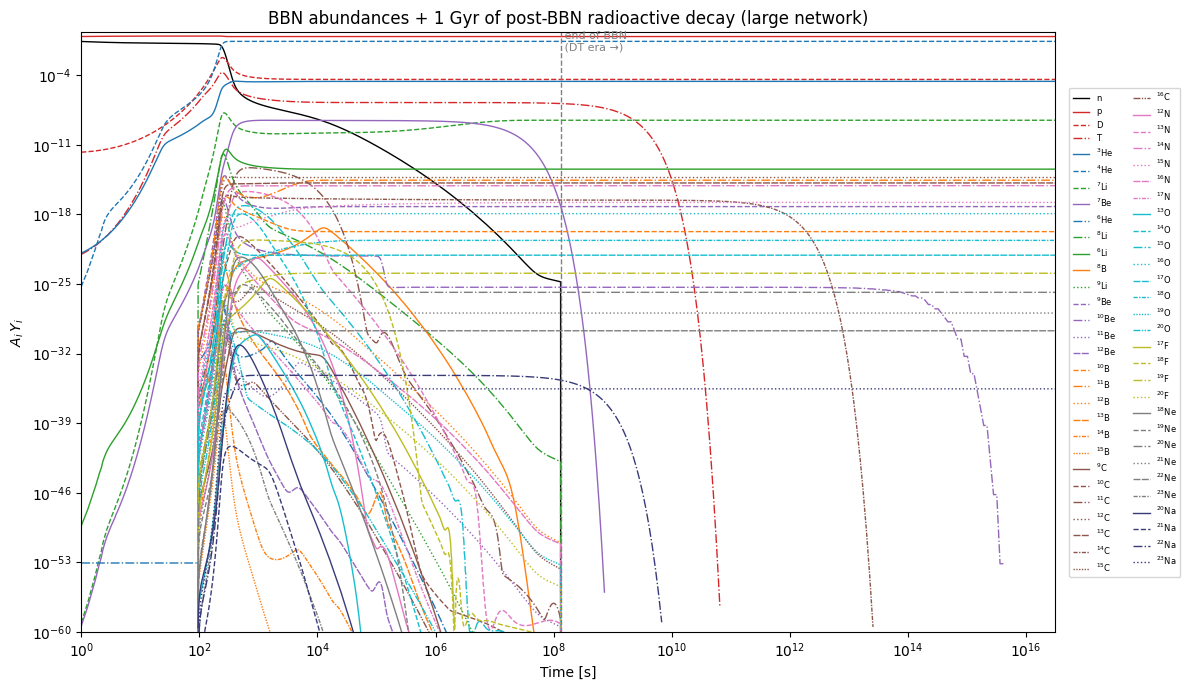

In [4]:
A = run.A                      # mass numbers, to plot A_i Y_i (per-baryon mass fraction)
styles = nuclide_styles(names) # element colour + isotope line style + label

# Very low plot floor so that even tiny-but-physical abundances (the free
# neutron tail ~1e-25, heavy nuclides ~1e-30, ...) are shown and not "cut" at
# the LT->DT boundary; we only drop strictly non-positive points (a log axis
# cannot show 0 / negative round-off), never positive values.
FLOOR = 1e-60
fig, ax = plt.subplots(figsize=(12, 7))
for s in names:
    color, ls, label = styles[s]
    vals = A[s] * Y_all[:, idx[s]]
    mask = vals > FLOOR
    if mask.any():
        ax.plot(t_all[mask], vals[mask], color=color, linestyle=ls, lw=1.0, label=label)

ax.axvline(t_end, color='grey', ls='--', lw=1.0)
ax.text(t_end, 3, ' end of BBN\n (DT era →)', va='top', fontsize=8, color='grey')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Time [s]'); ax.set_ylabel(r'$A_i\,Y_i$')
ax.set_xlim(1, t_all[-1]); ax.set_ylim(FLOOR, 2)
# Legend outside the axes, on the right, so it never hides any curve.
ax.legend(ncol=2, fontsize=6, loc='center left', bbox_to_anchor=(1.01, 0.5))
ax.set_title('BBN abundances + 1 Gyr of post-BBN radioactive decay (large network)')
fig.tight_layout()
plt.show()

## Zoom on the decay "steps"

The clearest physics is the conversion of unstable parents into their daughters.
We plot the number-fraction `Y` (not `A Y`) of each parent/daughter pair and mark
the parent's half-life with a vertical line: the parent falls by a factor of 2 at
each `T½` past `t_end`, and the daughter rises by the matching amount.

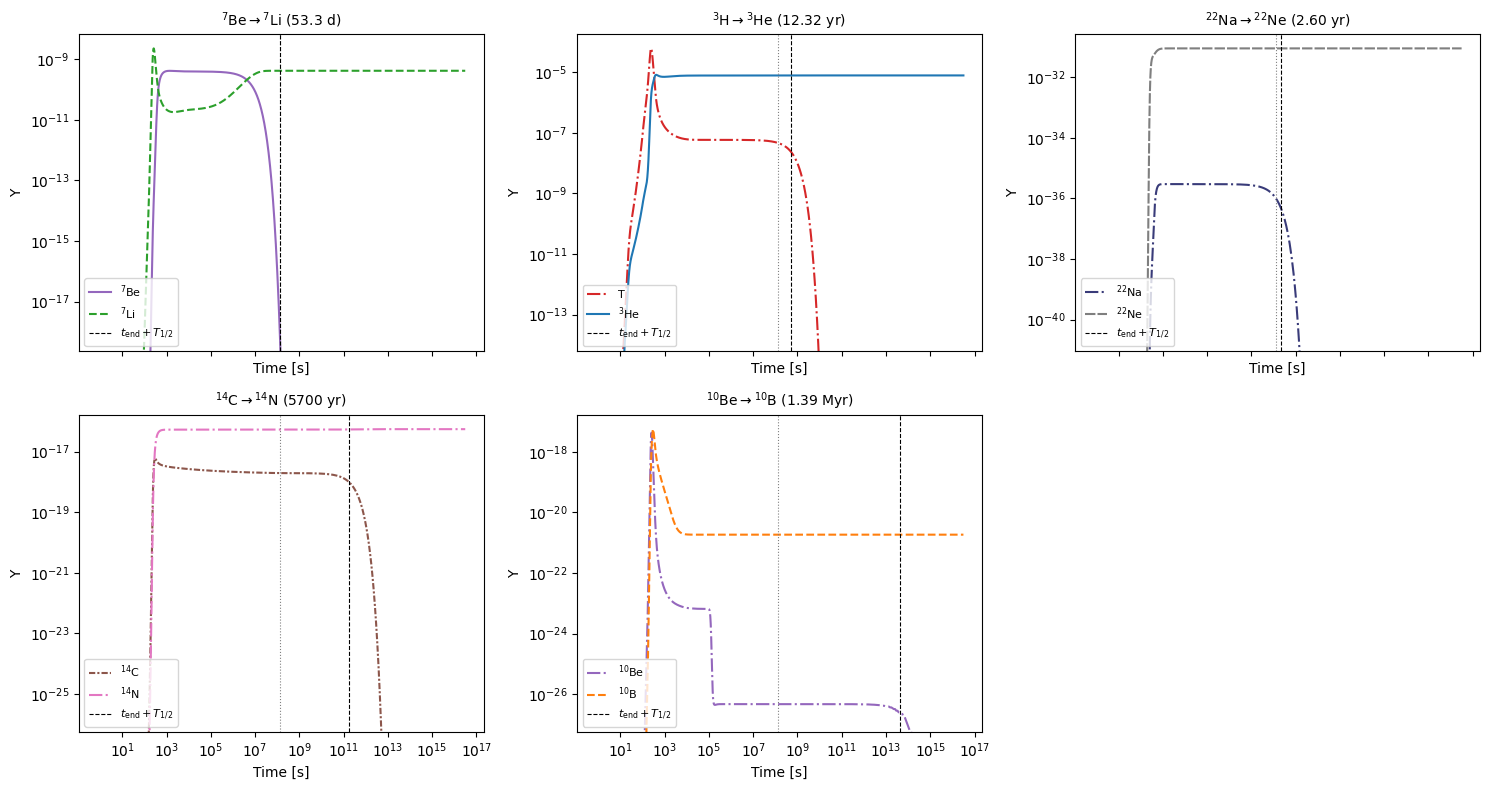

In [5]:
# (parent, daughter, half-life [s], panel title) -- half-lives from decays.txt.
pairs = [
    ('Be7', 'Li7', 4.604256e+06, r'$^7$Be$\to^7$Li (53.3 d)'),
    ('H3',  'He3', 3.887896e+08, r'$^3$H$\to^3$He (12.32 yr)'),
    ('Na22','Ne22',8.210797e+07, r'$^{22}$Na$\to^{22}$Ne (2.60 yr)'),
    ('C14', 'N14', 1.798745e+11, r'$^{14}$C$\to^{14}$N (5700 yr)'),
    ('Be10','B10', 4.376946e+13, r'$^{10}$Be$\to^{10}$B (1.39 Myr)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.ravel()
for ax, (par, dau, thalf, lab) in zip(axes, pairs):
    if par not in idx or dau not in idx:
        ax.set_visible(False)
        continue
    pc, pls, plab = styles[par]   # same element colour/isotope style as the big plot
    dc, dls, dlab = styles[dau]
    yp = Y_all[:, idx[par]]
    yd = Y_all[:, idx[dau]]
    ax.plot(t_all[yp > 0], yp[yp > 0], color=pc, linestyle=pls, label=plab)
    ax.plot(t_all[yd > 0], yd[yd > 0], color=dc, linestyle=dls, label=dlab)
    ax.axvline(t_end, color='grey', ls=':', lw=0.8)
    ax.axvline(t_end + thalf, color='k', ls='--', lw=0.8, label=r'$t_{\rm end}+T_{1/2}$')
    ax.set_xscale('log'); ax.set_yscale('log')
    # The parent decays to ~0 (matrix-exp underflow), so autoscale would blow
    # the y-range out to ~1e-280; clamp to ~10 decades below the peak so the
    # decay step stays readable.
    peak = max(yp.max(), yd.max())
    ax.set_ylim(peak * 1e-10, peak * 3.0)
    ax.set_title(lab, fontsize=10)
    ax.set_xlabel('Time [s]'); ax.set_ylabel('Y')
    ax.legend(fontsize=8, loc='lower left')
axes[-1].set_visible(False)   # only 5 pairs; hide the 6th panel
plt.tight_layout()
plt.show()

## Sanity check: baryon number is conserved through the DT era

The decay matrix `D` moves mass between nuclei (with daughters weighted by
`A_daughter / A_parent`), so $\sum_i A_i Y_i$ is conserved up to the tiny mass
carried off by emitted leptons/photons (bookkeeping pseudo-species, not in the
ODE state).  We expect drift well below 10⁻⁶.

In [6]:
A_vec = np.array([run.A[s] for s in names])
baryon = Y_all @ A_vec
rel_drift = np.max(np.abs(baryon - baryon[0])) / baryon[0]
print(f'max |Δ(Σ A_i Y_i)| / (Σ A_i Y_i) over the whole history = {rel_drift:.2e}')

max |Δ(Σ A_i Y_i)| / (Σ A_i Y_i) over the whole history = 1.83e-12


In [7]:
run['n'](2e6)

6.10502439044012e-17